# fx-blender: Multiband Timbral Blend

STFT-based prototype for per-band blending between two guitar effect chains.

```
GuitarSet DI → distortion → ┬─ A: dry distorted ──────────────┐
                             └─ B: octave up + chorus ──────────┤ blend → output
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.signal import stft, istft
from pedalboard import Pedalboard, Distortion, PitchShift, Chorus, Reverb
from pedalboard.io import AudioFile

## Configuration

In [2]:
AUDIO_PATH = r"D:\ruggbk\GitHub\neural-audio-effects\data\guitarset\audio\00_BN1-129-Eb_comp_mix.wav"
CLIP_DURATION = 10.0  # seconds to load

# LFO
LFO_RATE_HZ   = 0.5   # cycles per second — try 0.1 (slow morph) to 2.0 (flutter)
LFO_DEPTH     = 0.8   # 0-1 — controls swing; 0.8 means blend ranges from 0.1 to 0.9
PHASE_SPREAD  = np.pi # radians of phase offset across all bands — pi = half cycle

## Input Signal

Load a GuitarSet DI recording and apply distortion. Swap `AUDIO_PATH` for any distorted guitar recording to skip the distortion step.

In [5]:
with AudioFile(AUDIO_PATH) as f:
    sr = f.samplerate
    audio = f.read(int(CLIP_DURATION * sr))

# AudioFile returns (channels, samples) — mix to mono
#audio = audio.mean(axis=0)
audio = audio[0]  # take left channel only, instead of averaging stereo

distortion = Pedalboard([Distortion(drive_db=30)])
# distorted = distortion(audio[np.newaxis, :], sr).squeeze()
distorted = audio  # bypass distortion

distorted /= np.max(np.abs(distorted))

print(f"{len(audio)/sr:.1f}s at {sr}Hz")
print("Distorted input:")
display(Audio(distorted, rate=sr))

10.0s at 44100Hz
Distorted input:


## Effect B: Octave Up + Chorus

Pitch shift up one octave with detuned chorus for a synth-like texture.

In [6]:
effect_b_chain = Pedalboard([
    PitchShift(semitones=12),
    Chorus(rate_hz=0.6, depth=0.35, centre_delay_ms=7.0, feedback=0.2, mix=0.9),
])

effect_b = effect_b_chain(distorted[np.newaxis, :], sr).squeeze()
effect_b /= np.max(np.abs(effect_b))

sig_a, sig_b = distorted, effect_b

print("Effect B solo:")
display(Audio(effect_b, rate=sr))

Effect B solo:


## Global LFO Blend

Single LFO modulates the A/B blend across the full frequency spectrum simultaneously.

In [5]:
t = np.arange(len(sig_a)) / sr
blend = 0.5 + (LFO_DEPTH / 2) * np.sin(2 * np.pi * LFO_RATE_HZ * t)

output_global = blend * sig_a + (1 - blend) * sig_b
output_global /= np.max(np.abs(output_global))

print("Global blend output:")
display(Audio(output_global, rate=sr))

Global blend output:


## Phase 2: Multiband Blend with Phase Spread

Split into semitone-spaced frequency bands using STFT. Each band gets the same LFO rate but a different starting phase — so at any moment, some bands are in effect A while others are in effect B.

The STFT approach avoids the ringing/latency problem that time-domain bandpass filters have at low frequencies.

In [6]:
def semitone_bands(f_bins, f_min=80.0, f_max=5000.0, semitones_per_band=4):
    """Return list of (bin_lo, bin_hi) index pairs for semitone-spaced bands."""
    bands = []
    f_lo = f_min
    while f_lo < f_max:
        f_hi = f_lo * 2 ** (semitones_per_band / 12)
        lo = np.searchsorted(f_bins, f_lo)
        hi = np.searchsorted(f_bins, f_hi)
        if hi > lo:
            bands.append((lo, hi))
        f_lo = f_hi
    return bands


def multiband_blend(sig_a, sig_b, sr, rate_hz, depth, phase_spread, semitones_per_band=4):
    nperseg = 4096
    noverlap = nperseg * 3 // 4

    f_bins, t_frames, Za = stft(sig_a, fs=sr, nperseg=nperseg, noverlap=noverlap)
    _,      _,        Zb = stft(sig_b, fs=sr, nperseg=nperseg, noverlap=noverlap)

    bands = semitone_bands(f_bins, semitones_per_band=semitones_per_band)
    n_bands = len(bands)

    Z_out = Za.copy()  # bins outside the guitar range pass through as dry

    for i, (lo, hi) in enumerate(bands):
        phase_offset = i * phase_spread / max(n_bands - 1, 1)
        blend = 0.5 + (depth / 2) * np.sin(2 * np.pi * rate_hz * t_frames + phase_offset)
        Z_out[lo:hi, :] = blend * Za[lo:hi, :] + (1 - blend) * Zb[lo:hi, :]

    _, output = istft(Z_out, fs=sr, nperseg=nperseg, noverlap=noverlap)
    # trim to input length (istft may add a few samples)
    output = output[:len(sig_a)]
    output /= np.max(np.abs(output))
    return output, bands, n_bands

In [7]:
output_mb, bands, n_bands = multiband_blend(
    sig_a, sig_b, sr,
    rate_hz=LFO_RATE_HZ,
    depth=LFO_DEPTH,
    phase_spread=PHASE_SPREAD,
)

print(f"{n_bands} bands, {n_bands * 4} semitones covered")
print("Multiband blend output:")
display(Audio(output_mb, rate=sr))

18 bands, 72 semitones covered
Multiband blend output:


## Visualize the Phase Spread

Each row is a frequency band. Color shows blend value (yellow = mostly A/dry, purple = mostly B/synth). The diagonal wave pattern is the phase spread — at any moment in time, different bands are at different points in the LFO cycle.

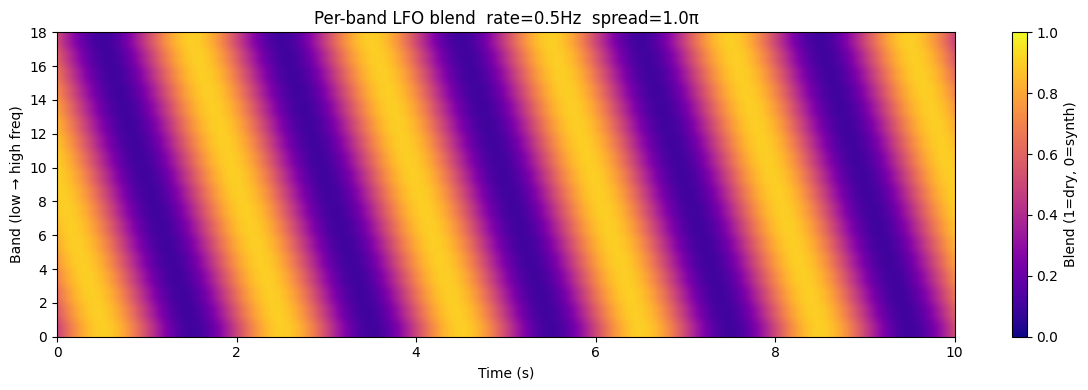

In [8]:
nperseg  = 4096
noverlap = nperseg * 3 // 4
_, t_frames, _ = stft(distorted, fs=sr, nperseg=nperseg, noverlap=noverlap)

blend_map = np.zeros((n_bands, len(t_frames)))
for i in range(n_bands):
    phase_offset = i * PHASE_SPREAD / max(n_bands - 1, 1)
    blend_map[i] = 0.5 + (LFO_DEPTH / 2) * np.sin(2 * np.pi * LFO_RATE_HZ * t_frames + phase_offset)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(blend_map, aspect='auto', origin='lower',
               extent=[t_frames[0], t_frames[-1], 0, n_bands],
               vmin=0, vmax=1, cmap='plasma')
plt.colorbar(im, ax=ax, label='Blend (1=dry, 0=synth)')
ax.set(xlabel='Time (s)', ylabel='Band (low → high freq)',
       title=f'Per-band LFO blend  rate={LFO_RATE_HZ}Hz  spread={PHASE_SPREAD/np.pi:.1f}π')
plt.tight_layout()
plt.show()

## Static Per-Band Blend

Fixed blend value per frequency band with no time modulation. Maps specific note ranges consistently to effect A or B. `BLEND_SHAPE` controls the transition curve across the frequency range.

In [22]:
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def freq_to_note(f):
    midi = round(12 * np.log2(f / 440) + 69)
    return f"{NOTE_NAMES[midi % 12]}{midi // 12 - 1}"


def static_multiband_blend(sig_a, sig_b, sr, blend_per_band, semitones_per_band=4):
    """Apply a fixed blend value per band. blend_per_band[i]=1 → fully A, 0 → fully B."""
    nperseg = 4096
    noverlap = nperseg * 3 // 4

    f_bins, _, Za = stft(sig_a, fs=sr, nperseg=nperseg, noverlap=noverlap)
    _,      _, Zb = stft(sig_b, fs=sr, nperseg=nperseg, noverlap=noverlap)

    bands = semitone_bands(f_bins, semitones_per_band=semitones_per_band)

    Z_out = Za.copy()
    for i, (lo, hi) in enumerate(bands):
        b = blend_per_band[i]
        Z_out[lo:hi, :] = b * Za[lo:hi, :] + (1 - b) * Zb[lo:hi, :]

    _, output = istft(Z_out, fs=sr, nperseg=nperseg, noverlap=noverlap)
    output = output[:len(sig_a)]
    output /= np.max(np.abs(output))
    return output, bands

In [23]:
SWAP_AB = False  # True to swap A and B
SEMITONES_PER_BAND = 1
BLEND_STRENGTH = 1.0  # 0-1, how far each band leans from center
BLEND_SHAPE = 'linear'  # 'sine' | 'linear' | 'step'

nperseg = 4096
_a, _b = (effect_b, distorted) if SWAP_AB else (distorted, effect_b)
f_bins, _, _ = stft(_a, fs=sr, nperseg=nperseg, noverlap=nperseg * 3 // 4)
bands_static = semitone_bands(f_bins, semitones_per_band=SEMITONES_PER_BAND)
n = len(bands_static)

if BLEND_SHAPE == 'sine':
    blend_per_band = 0.5 + (BLEND_STRENGTH / 2) * np.cos(np.linspace(0, np.pi, n))
elif BLEND_SHAPE == 'linear':
    blend_per_band = 0.5 + (BLEND_STRENGTH / 2) * np.linspace(1, -1, n)
elif BLEND_SHAPE == 'step':
    blend_per_band = np.where(np.arange(n) % 2 == 0,
                              0.5 + BLEND_STRENGTH / 2,
                              0.5 - BLEND_STRENGTH / 2)

output_static, bands_static = static_multiband_blend(
    _a, _b, sr, blend_per_band, semitones_per_band=SEMITONES_PER_BAND)

print(f"{n} bands  |  shape={BLEND_SHAPE}  strength={BLEND_STRENGTH}  swap={SWAP_AB}")
print("Static per-band blend output:")
display(Audio(output_static, rate=sr))

67 bands  |  shape=linear  strength=1.0  swap=False
Static per-band blend output:


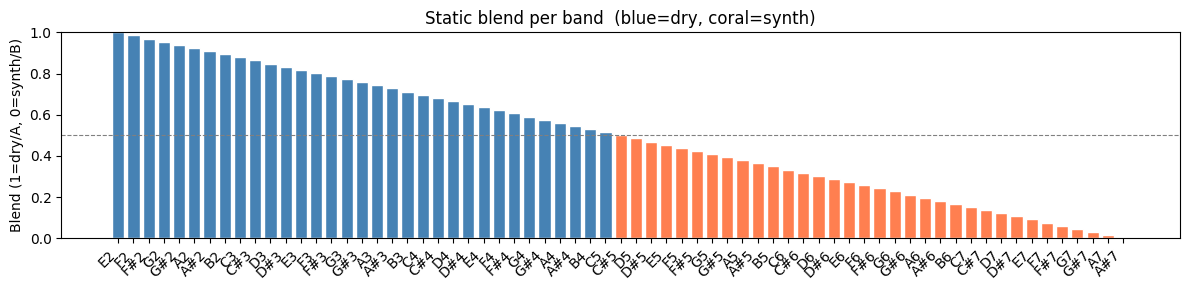

In [24]:
# Show which note ranges land in which effect
band_centers = []
f_lo = 80.0
for _ in bands_static:
    f_hi = f_lo * 2 ** (SEMITONES_PER_BAND / 12)
    band_centers.append(np.sqrt(f_lo * f_hi))  # geometric mean
    f_lo = f_hi

labels = [freq_to_note(f) for f in band_centers]
colors = ['steelblue' if b > 0.5 else 'coral' for b in blend_per_band]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(n), blend_per_band, color=colors, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set(ylabel='Blend (1=dry/A, 0=synth/B)', ylim=(0, 1),
       title='Static blend per band  (blue=dry, coral=synth)')
plt.tight_layout()
plt.show()

## Experiment

**In the config cell:**

| Parameter | Effect |
|---|---|
| `LFO_RATE_HZ` | Speed of the sweep — try 0.1 to 2.0 |
| `LFO_DEPTH` | How far it swings — 1.0 is full A↔B |
| `PHASE_SPREAD` | `np.pi` = half cycle between lowest and highest band; `2*np.pi` = full cycle |

**In `multiband_blend()`:**
- `semitones_per_band=3` for more bands (finer resolution)
- `semitones_per_band=6` for fewer bands (coarser, more dramatic per-band shift)

**In the Effect B cell:**
- `PitchShift(semitones=7)` — perfect fifth (warmer)
- `PitchShift(semitones=24)` — two octaves (very synthy)
- Add `Reverb(room_size=0.6, wet_level=0.4)` for more space